<a href="https://colab.research.google.com/github/terry0809000/Artificial-Intelligence-KCL/blob/main/7PAVAIHA_2026_Practical_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 2: Constraint Optimisation and Graph Searching

<hr style="border:1px solid black"> </hr>

## IMPORTANT

Please save your own copy of this workbook and work off that. Click on `File` and select `Save a copy in Drive`

Then, click on `Runtime` above and if highlighted, click on `Restart session`

Finally, click on `edit` above and click on `Clear all outputs`

**Run time**
Note, you will only need the CPU for this practical

For the first part of the practical, we want to make sure Google Colab is using the CPU runtime (not GPU).

Step 1: Open Runtime Settings
*   Click Runtime in the top menu.
*   Click Change runtime type.

Step 2: Select CPU, then click on Save

<hr style="border:1px solid black"> </hr>

## Using AI Assistants During the Exercises

In this module, you are permitted to use ChatGPT, Gemini, or Copilot to help you understand concepts, debug code, or develop solutions.

If you choose to use an AI assistant, you must:

1.   Keep track of the prompts you use
2.   Summarise the responses you found useful
3.   Write a short reflection explaining how the AI helped your learning

Your reflection should briefly consider:

*   What you asked the AI
*   What you learned from the response
*   Whether the response was helpful, incomplete, or incorrect

### Example AI Interaction Log

Prompt:

Response summary:

What I learned from this interaction:

Was the AI response correct/helpful? Why or why not?

<hr style="border:1px solid black"> </hr>

## Exercise 1: Introduction to Constraint Satisfaction

The aim of this lab is to provide an overview of the main concepts of constraint satisfaction problems through a worked example

**Problem:** A pandemic is rising. Hospitals must organize quickly to treat ill people.
We need to design algorithm which matches infected people and hospitals together given multiple criteria such as the severity of illness, patient age and location, hospital capacity and equipment, etc.

**Exercise:** Briefly explain the following concepts:

- The difference between **constraint satisfaction problems (CSP)** and **graph search algorithms**, in simple terms.

- Why a **constraint satisfaction approach** is suitable for the hospital allocation problem described above.

- What **other AI methods** could potentially be used to solve this problem.

- The difference between **hard constraints** and **soft constraints** in CSP.

<hr style="border:1px solid black"> </hr>

**Exercise:** Modelling the Problem

Using your understanding from the previous exercise, think about how the hospital allocation problem could be modelled as a CSP.

Identify the following:

- **Variables:** What decisions must be made? (e.g., assigning patients to hospitals or beds)

- **Domains:** What possible values can each variable take?

- **Constraints:** What rules must always be satisfied? List at least three.

- **Soft constraints:** What preferences might improve the solution but are not strictly required?

Briefly describe your ideas.

<hr style="border:1px solid black"> </hr>

### OR-Tools

We will use the __[OR-Tools](https://developers.google.com/optimization)__ to solve our optimisation problem

Remember to install the OR-Tools module *before* starting the tutorial:  

In [1]:
pip install ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 13.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.5 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.

Import all toolboxes need to support the tutorial

In [2]:
from ortools.sat.python import cp_model # CP-SAT solver

import numpy as np
from random import randint
from math import ceil
import matplotlib.pyplot as plt # Data visualization

<hr style="border:1px solid black"> </hr>

### Declare Key Parameters

Our problem space has **four key parameters** that define the model.

**Exercise:**

- Identify these parameters by examining the code below.

- Based on these values, will every patient get a bed?

In [3]:
# Number of hospitals
n_hospitals = 3
# Number of infected people
n_patients = 200
# Number of beds in every hospital
n_beds_in_hospitals = [30,50,20]
# Location of infected people -- random integer tuple (x,y)
patients_loc = [(randint(0, 100), randint(0, 100)) for _ in range(n_patients)]
# Location of hospitals -- random integer tuple (x,y)
hospitals_loc = [(randint(0, 100), randint(0, 100)) for _ in range(n_hospitals)]
# Illness severity -- 1 = mild -> 5 = severe
patients_severity = [randint(1, 5) for _ in range(n_patients)]

<hr style="border:1px solid black"> </hr>

### Visualise the problem space

**Exercise:**

- Add comments to each line of code explaining its purpose

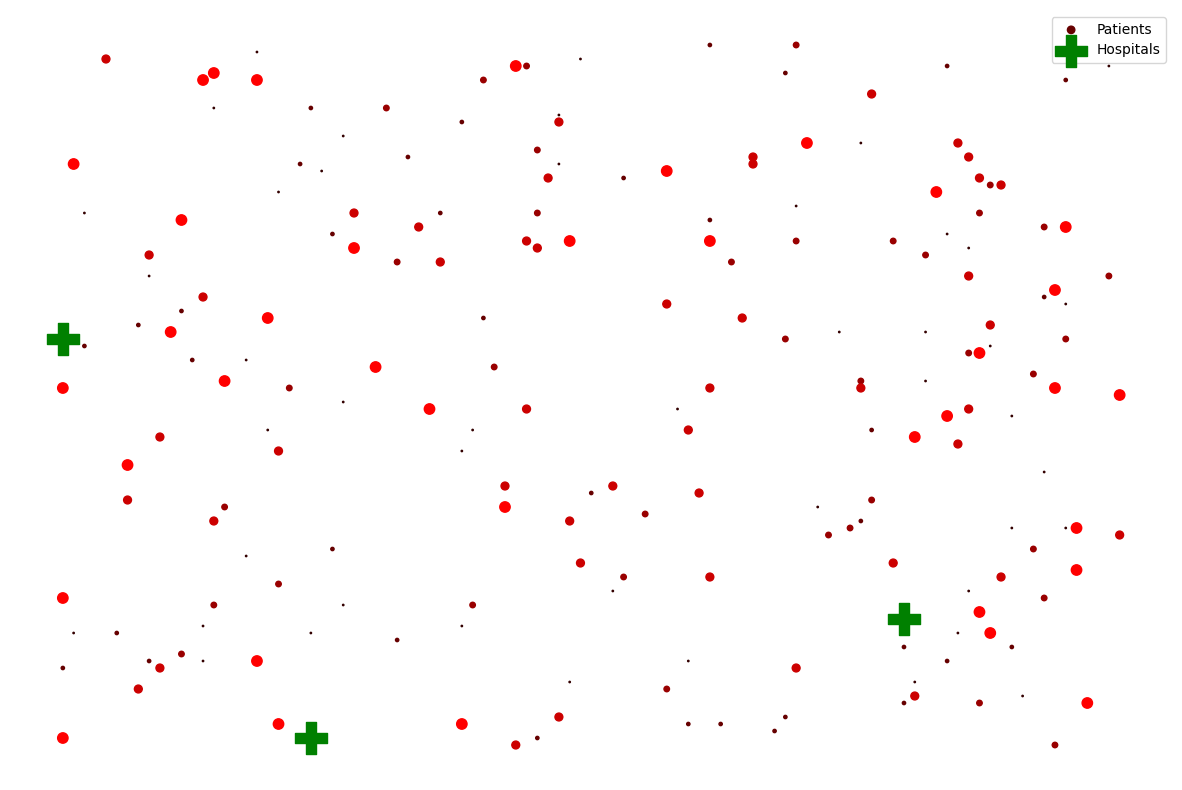

In [4]:
# Visualization
plt.rcParams["figure.figsize"] = (15,10)
# Set the size of the figure to 15 inches wide and 10 inches high for better visibility.

shade_severity = [int(sev*255/5) for sev in patients_severity]
# Convert patient severity scores into a value between 0 and 255.
# This will later be used to control the intensity of the red color (higher severity → darker red).

color_severity = ["#%02x0000" % (sev) for sev in shade_severity]
# Create color codes in hexadecimal format.
# The red component is determined by the severity level, while green and blue are 0.
# This means higher severity patients appear as darker red points.

size_severity = [k**2.5 for k in patients_severity]
# Determine the size of each point in the plot.
# Higher severity values produce larger marker sizes to make severe patients more visible.

plt.scatter(*zip(*patients_loc), s=size_severity, c=color_severity, label="Patients")
# Plot patient locations as scatter points.
# zip(*patients_loc) separates x and y coordinates.
# Marker size reflects severity, and color indicates severity intensity.

plt.scatter(*zip(*hospitals_loc), s=500, c="g", marker="P", label="Hospitals")
# Plot hospital locations.
# Points are large (size 500), colored green, and use the "P" marker shape to distinguish hospitals.

plt.legend()
# Display a legend to identify patients and hospitals in the plot.

plt.axis('off')
# Remove axis lines and tick labels to make the visualization cleaner.

plt.show()
# Render and display the final plot.

<hr style="border:1px solid black"> </hr>

### Declare Constraint Variables

A constraint satisfaction problem consists of a set of variables that must be assigned values such that a set of constraints is satisfied.

- `i` represents a hospital
- `j` represents a bed in hospital `i`
- `k` represents a patient

**Exercise:**
- Explain how the code below represents patient–bed assignments.
- What would it mean if `x[2,5,7] = 1` in this model?

In [5]:
model = cp_model.CpModel()
x = {}
for i in range(n_hospitals):
  for j in range(n_beds_in_hospitals[i]):
    for k in range(n_patients):
      x[(i,j,k)] = model.NewBoolVar("x(%d,%d,%d)" % (i,j,k))

#patient 7 is assigned to bed 5 in hospital 2
#The code defines binary decision variables to represent whether a patient is assigned to a specific hospital bed.
#i hospital

<hr style="border:1px solid black"> </hr>

### Goal of our problem:
    
In order to associate each bed of an hospital to an ill person, we must find a set of variables (*n* unique combinations of `x[i,j,k] = 1`) that satisfies all of our constraints.

**Question:** what is the maximum value of *n*? Why?

<hr style="border:1px solid black"> </hr>

### Hard Constraints

Hard constraints define the rules that must be satisfied for a solution to be valid. If they are not satisfied, the problem cannot be solved.

**Exercise:** Based on the code below, identify the hard constraints and briefly describe the difference between them.

In [ ]:
# Constraint #1
for i in range(n_hospitals):
  for j in range(n_beds_in_hospitals[i]):
    model.Add(sum(x[(i,j,k)] for k in range(n_patients)) <= 1)

# Constraint #2
for k in range(n_patients):
  inner_sum = []
  for i in range(n_hospitals):
    inner_sum.append(sum(x[(i,j,k)] for j in range(n_beds_in_hospitals[i])))
  model.Add(sum(inner_sum) <= 1)

<hr style="border:1px solid black"> </hr>

### Soft Constraints

Soft constraints represent preferences in the model. The solution should try to satisfy them as much as possible, but they are not strictly required for a valid solution.

**Exercise:** Based on the code below, identify the soft constraints and briefly describe the differences between them.

In [ ]:
# Integer distance function
idist = lambda xy1, xy2: int(((xy1[0]-xy2[0])**2 + (xy1[1]-xy2[1])**2)**0.5)

# Gain factors (1/penalty factors)
gain_max_patients = 140
gain_severity = int(140/5)
gain_distance = -1

# Maximization objective
soft_csts = []
for i in range(n_hospitals):
  for j in range(n_beds_in_hospitals[i]):
    for k in range(n_patients):
      factor = \
        gain_max_patients \
        + gain_distance * idist(hospitals_loc[i], patients_loc[k]) \
        + gain_severity * patients_severity[k]
      soft_csts.append(factor * x[(i,j,k)])

model.Maximize(sum(soft_csts))

**Exercise:** What is the difference between how hard constraints and soft constraints are expressed in the model?

<hr style="border:1px solid black"> </hr>

### Run Solver
Now we can launch the solver. As the optimal solution may take time to find, this code is set up to find the optimal solution within a specified time limit. If it can’t manage to find the optimal solution, it will return the closest sub-optimal solution.

In [ ]:
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 60
status = solver.Solve(model)

### Print out patient assignments

**Exercise:**

- Add comments to each line of code explaining its purpose

In [ ]:
plot_lines = [[] for _ in range(n_hospitals)]
for i in range(n_hospitals):
  print("Hospital ", i)
  for j in range(n_beds_in_hospitals[i]):
    for k in range(n_patients):
      if solver.Value(x[(i,j,k)]) == 1:
        print("\tPatient ", k, "in bed ", j)
        line_abs = [ hospitals_loc[i][0], patients_loc[k][0] ]
        line_ord = [ hospitals_loc[i][1], patients_loc[k][1] ]
        plot_lines[i].append([line_abs, line_ord])
print()
print("Inference time: %f s" % solver.WallTime())

Hospital  0
	Patient  2 in bed  0
	Patient  76 in bed  1
	Patient  87 in bed  2
	Patient  19 in bed  3
	Patient  149 in bed  4
	Patient  118 in bed  5
	Patient  51 in bed  6
	Patient  127 in bed  7
	Patient  27 in bed  8
	Patient  100 in bed  9
	Patient  172 in bed  10
	Patient  34 in bed  11
	Patient  46 in bed  12
	Patient  28 in bed  13
	Patient  57 in bed  14
	Patient  86 in bed  15
	Patient  90 in bed  16
	Patient  56 in bed  17
	Patient  98 in bed  18
	Patient  123 in bed  19
	Patient  69 in bed  20
	Patient  180 in bed  21
	Patient  96 in bed  22
	Patient  147 in bed  23
	Patient  171 in bed  24
	Patient  71 in bed  25
	Patient  18 in bed  26
	Patient  177 in bed  27
	Patient  159 in bed  28
	Patient  4 in bed  29
Hospital  1
	Patient  178 in bed  0
	Patient  114 in bed  1
	Patient  32 in bed  2
	Patient  198 in bed  3
	Patient  112 in bed  4
	Patient  107 in bed  5
	Patient  65 in bed  6
	Patient  197 in bed  7
	Patient  102 in bed  8
	Patient  52 in bed  9
	Patient  91 in bed 

### Visualise Results

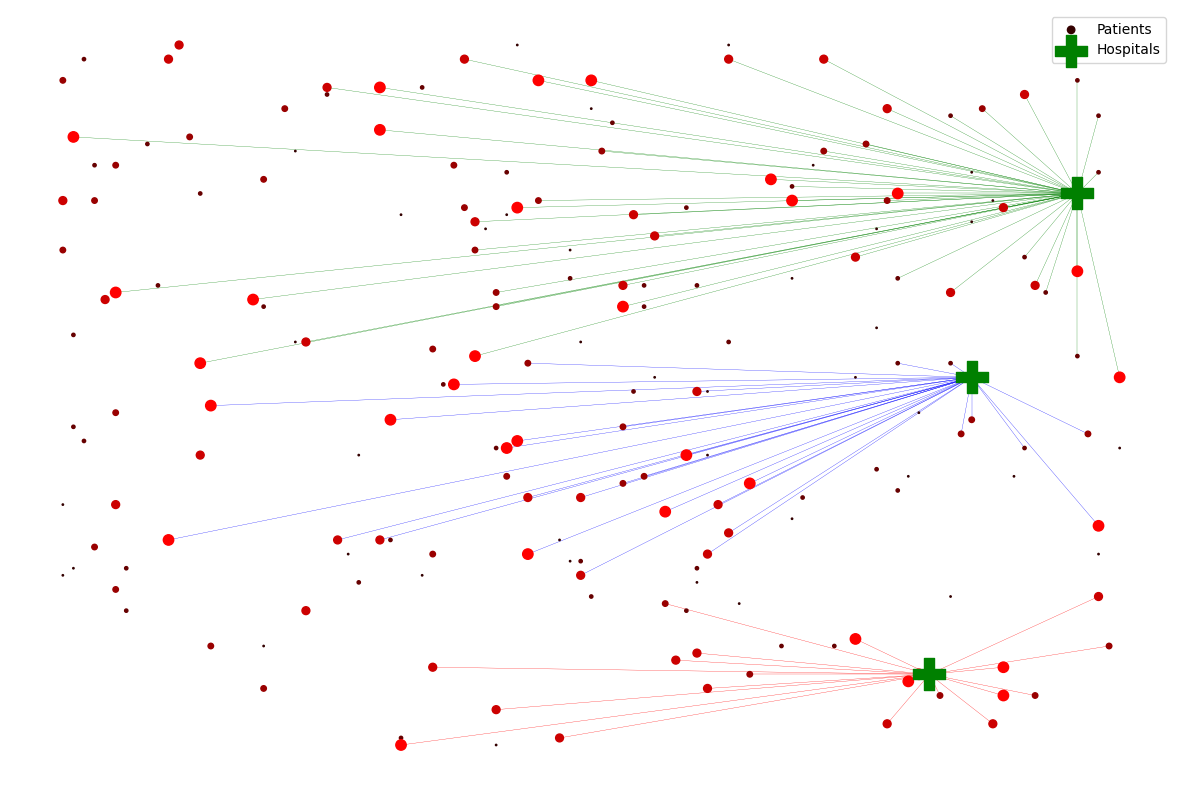

In [ ]:
from itertools import cycle

shade_severity = [int(sev*255/5) for sev in patients_severity]
color_severity = ["#%02x0000" % (sev) for sev in shade_severity]
size_severity = [k**2.5 for k in patients_severity]
plt.scatter(*zip(*patients_loc), s=size_severity, c=color_severity, label="Patients", zorder=2)
plt.scatter(*zip(*hospitals_loc), s=500, c="g", marker="P", label="Hospitals", zorder=3)
colors = cycle('bgrcmk')
for i in range(n_hospitals):
  c = next(colors)
  for (x_,y_) in plot_lines[i]:
    plt.plot(x_,y_,c=c,linewidth=0.2, zorder=1)
plt.legend()
plt.axis('off')
plt.show()

<hr style="border:1px solid black"> </hr>

## Simulation Experiments

### Simulation Experiments

Constraint satisfaction models allow us to quickly explore different scenarios by changing parameters and solving the problem again.

**Exercise:** Experiment with the model by changing the core parameters and running at least **six different simulations**.

For each simulation, record:
- the parameter values you changed
- whether all patients were assigned a bed
- how the assignments differ from the previous runs

Example scenarios to explore:

- Increase the number of patients
- Change the number of hospitals or vary hospital capacity
- Modify the hard or soft constraints
- Combine several changes at once

Briefly compare the outputs and describe how these changes affect the solution.

Try to find combinations of parameters that make the problem **more difficult or impossible to solve**.

Describe what changes you made and explain why they make the constraints harder to satisfy.

<hr style="border:1px solid black"> </hr>

## Excercise 2: Implement your own Breadth and Depth Search

In this exercise you will implement a *Depth-First Search* (DFS) and *Breadth-First Search* (BFS) algorithm on a graph representation known as an __[adjacency list](https://www.khanacademy.org/computing/computer-science/algorithms/graph-representation/a/representing-graphs)__, which is stored as a __[dictionary](https://www.tutorialspoint.com/python3/python_dictionary.htm)__ data type in Python.

**Reflection:**

Before you begin coding, reflect on the lecture material on **Breadth-First Search (BFS)** and **Depth-First Search (DFS)**.

**Question:** How does the way nodes are stored and retrieved during the search influence the order in which nodes are explored?

**Exercise**

Implement your own versions of **BFS** and **DFS** for the graph defined below.

Your functions should:

- take a **graph (adjacency list)** and a **starting node** as input
- visit all reachable nodes in the graph
- return the **order in which nodes are visited**
- include comments explaining the core functionality

Test your implementations starting from node **S**, and compare the order in which nodes are visited by BFS and DFS.



In [ ]:
# adjacency list
adj_1 = {
    'S': ['A', 'B', 'C'],
    'A': ['S', 'D', 'E'],
    'B': ['S', 'F'],
    'C': ['S', 'G'],
    'D': ['A', 'H'],
    'E': ['A', 'I'],
    'F': ['B', 'J'],
    'G': ['C'],
    'H': ['D', 'K'],
    'I': ['E'],
    'J': ['F'],
    'K': ['H']
}

<hr style="border:1px solid black"> </hr>